In [17]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

In [30]:
lattice_str = "kagome"
lattice_len = 7
lattice_dim = (lattice_len, lattice_len)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str, overwrite_param = overwrite_param)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

# Add offset to the bare model
sys_len = 0
sys_range = ((lattice_len - sys_len) // 2, (lattice_len + sys_len) // 2)
n_sys = sys_len**2
V_rsv_offset = 0.
# Find what unit cells are in the reservoir by excluding the unit cells in the system
sys_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1]) if sys_range[0] <= jj and jj < sys_range[1]
                                    for ii in range(my_tb_model.lat_dim[0]) if sys_range[0] <= ii and ii < sys_range[1]])
rsv_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1])
                                    for ii in range(my_tb_model.lat_dim[0])])
rsv_natural_uc_ind -= sys_natural_uc_ind
rsv_natural_uc_ind = np.array(list(rsv_natural_uc_ind))
logging.debug(rsv_natural_uc_ind)
rsv_ind = np.hstack(
    [my_tb_model.get_reduced_index(rsv_natural_uc_ind[:,0], rsv_natural_uc_ind[:,1], k)
        for k in range(my_tb_model.n_basis)])

H_offset = np.zeros_like(H_bare)
H_offset[rsv_ind, rsv_ind] = V_rsv_offset
H_total = H_bare + H_offset

In [33]:
CLS_pos_list = [(2, 2, 2)] # the "reduced index" of the lower corner of hexagons
def plot_kag_CLS(ax, tb_model: E9tb.tbmodel_2D, pos):
    i, j, k = pos
    if k != 2: raise(ValueError("wrong CLS position (it's the bottom site)"))
    all_corners = [(i, j, 2), (i, j, 1), (i + 1, j, 0),
                   (i + 1, j, 2), (i, j + 1, 1), (i, j + 1, 0)]
    ac_roll = all_corners[1::] + [all_corners[0]]
    filled_pos = all_corners[::2]

    CLS_dict = {"color": "blue", "linewidth": 3}
    site1_dict = {"color": "blue", "edgecolors": "blue", "linewidth": 2}
    site2_dict = {"color": "white", "edgecolors": "blue", "linewidth": 2}
    for p1, p2 in zip(all_corners, ac_roll):
        pos1 = tb_model.get_lat_pos(p1)
        pos2 = tb_model.get_lat_pos(p2)
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], **CLS_dict)
        if p1 in filled_pos:
            ax.scatter(*pos1, **site1_dict, zorder = 100)
        else:
            ax.scatter(*pos1, **site2_dict, zorder = 100)

def plot_kag_NLS1(ax, tb_model: E9tb.tbmodel_2D, j_pos):
    Ni = tb_model.lat_dim[0]
    all_k0 = [(i, j_pos, 0) for i in range(Ni)]
    all_k1 = [(i, j_pos, 1) for i in range(Ni)]
    all_sites = [item for pair in zip(all_k0, all_k1) for item in pair]
    filled_pos = all_k0

    CLS_dict = {"color": "red", "linewidth": 3}
    site1_dict = {"color": "red", "edgecolors": "red", "linewidth": 2}
    site2_dict = {"color": "white", "edgecolors": "red", "linewidth": 2}
    for p1, p2 in zip(all_sites[:-1], all_sites[1:]):
        pos1 = tb_model.get_lat_pos(p1)
        pos2 = tb_model.get_lat_pos(p2)
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], **CLS_dict)
        if p1 in filled_pos:
            ax.scatter(*pos1, **site1_dict, zorder = 100)
        else:
            ax.scatter(*pos1, **site2_dict, zorder = 100)

def plot_kag_NLS2(ax, tb_model: E9tb.tbmodel_2D, i_pos):
    Nj = tb_model.lat_dim[1]
    all_k0 = [(i_pos, j, 0) for j in range(Nj)]
    all_k2 = [(i_pos, j, 2) for j in range(Nj)]
    all_sites = [item for pair in zip(all_k0, all_k2) for item in pair]
    filled_pos = all_k0

    CLS_dict = {"color": "green", "linewidth": 3}
    site1_dict = {"color": "green", "edgecolors": "green", "linewidth": 2}
    site2_dict = {"color": "white", "edgecolors": "green", "linewidth": 2}
    for p1, p2 in zip(all_sites[:-1], all_sites[1:]):
        pos1 = tb_model.get_lat_pos(p1)
        pos2 = tb_model.get_lat_pos(p2)
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], **CLS_dict)
        if p1 in filled_pos:
            ax.scatter(*pos1, **site1_dict, zorder = 100)
        else:
            ax.scatter(*pos1, **site2_dict, zorder = 100)

TypeError: Patch.set_linestyle() got an unexpected keyword argument 'dashes'

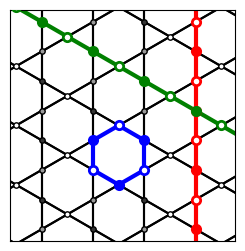

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (3, 3))


my_tb_model.plot_H(ax = ax, H = H_total,
                sublat_colors = ["#333333", "#999999", "#FFFFFF"],
                sublat_kwargs = {"edgecolors": "black",
                                    "linewidths": 1})

for pos in CLS_pos_list:
    plot_kag_CLS(ax, my_tb_model, pos)
plot_kag_NLS1(ax, my_tb_model, 1)
plot_kag_NLS2(ax, my_tb_model, 4)
ax.set_xlim(-4, -0.2)
ax.set_ylim(2.3, 6.2)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_linestyle("--")

fig.tight_layout()

thesis_fig_path_app = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\introduction")
file_name = "kagome_with_CLS.pdf"
file_full_path = Path(thesis_fig_path_app, file_name)
# fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')